<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ci%C3%AAncias_de_Dados_Aula6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A biblioteca Pandas e Dados em Painel

por **Cibele Russo**

**ICMC/USP - São Carlos SP**





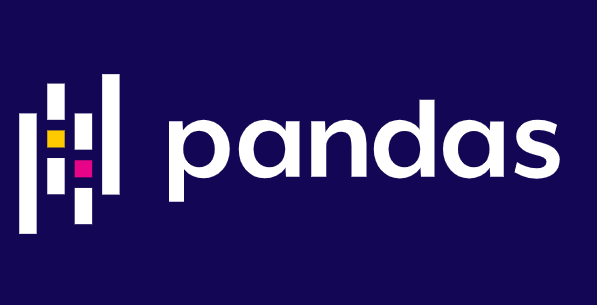

## Histórico do pandas

A biblioteca **pandas** foi criada por **Wes McKinney** em 2008, inicialmente para facilitar a manipulação e análise de dados tabulares no mercado financeiro.

O nome **pandas** está associado à expressão **panel data**, isto é, **dados em painel**, além da ideia de *data analysis*.

Com o tempo, a biblioteca se tornou uma das ferramentas mais importantes do ecossistema de ciência de dados em Python, sendo amplamente usada para:

- leitura de arquivos CSV e Excel
- limpeza e transformação de dados
- análise exploratória
- preparação de dados para modelagem estatística e aprendizado de máquina

## O que são dados em painel?

**Dados em painel** são dados que acompanham **várias unidades ao longo do tempo**.

Eles combinam duas dimensões:

- **dimensão transversal**: várias unidades, indivíduos, empresas, lojas, países, alunos etc.
- **dimensão temporal**: vários períodos, como dias, meses, anos ou semestres

### Exemplos

- vendas de várias lojas ao longo dos meses
- PIB de vários países ao longo dos anos
- notas de vários alunos ao longo dos semestres

### Exemplo conceitual
| Loja   | Mês | Vendas |
| ------ | --- | -----: |
| Loja A | Jan |    100 |
| Loja A | Fev |    120 |
| Loja A | Mar |    115 |
| Loja A | Abr |    130 |
| Loja B | Jan |     80 |
| Loja B | Fev |     90 |
| Loja B | Mar |     95 |
| Loja B | Abr |    105 |
| Loja C | Jan |    150 |
| Loja C | Fev |    160 |
| Loja C | Mar |    158 |
| Loja C | Abr |    170 |


Nesse tipo de estrutura, cada unidade aparece mais de uma vez, porque é observada em diferentes momentos do tempo.

### Por que isso é importante?

Dados em painel permitem estudar:

- evolução temporal
- diferenças entre unidades
- padrões mais ricos do que em dados puramente transversais ou puramente temporais

In [42]:
import pandas as pd
import numpy as np

## Estrutura 1: Series

Uma **Series** é uma estrutura **unidimensional** do pandas.

Ela pode ser vista como um vetor com:

- valores
- índices associados a esses valores

In [43]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
s

,0
a,10
b,20
c,30


In [44]:
print("Valores:")
print(s.values)

print("\nÍndices:")
print(s.index)

print("\nMultiplicação por 2:")
print(s * 2)

Valores:
[10 20 30]

Índices:
Index(['a', 'b', 'c'], dtype='object')

Multiplicação por 2:
a    20
b    40
c    60
dtype: int64


## Estrutura 2: DataFrame

Um **DataFrame** é uma estrutura **bidimensional**, organizada em linhas e colunas.

Ele é muito parecido com uma planilha.

In [45]:
df = pd.DataFrame({
    "Nome": ["Ana", "Bruno", "Carlos"],
    "Idade": [23, 35, 29],
    "Nota": [8.5, 7.0, 9.2]
})

df

,Nome,Idade,Nota
0,Ana,23,8.5
1,Bruno,35,7.0
2,Carlos,29,9.2


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nome    3 non-null      object 
 1   Idade   3 non-null      int64  
 2   Nota    3 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 204.0+ bytes


In [47]:
df.describe()

,Idade,Nota
count,3.0,3.000000
mean,29.0,8.233333
std,6.0,1.123981
min,23.0,7.000000
25%,26.0,7.750000
50%,29.0,8.500000
75%,32.0,8.850000
max,35.0,9.200000


## Estrutura 3: Dados em painel

In [48]:
import pandas as pd

dados = {
    "Loja": ["A","A","A","A","B","B","B","B","C","C","C","C"],
    "Mês": ["Jan","Fev","Mar","Abr","Jan","Fev","Mar","Abr","Jan","Fev","Mar","Abr"],
    "Vendas": [100,120,115,130,80,90,95,105,150,160,158,170]
}

df = pd.DataFrame(dados)
df

,Loja,Mês,Vendas
0,A,Jan,100
1,A,Fev,120
2,A,Mar,115
3,A,Abr,130
4,B,Jan,80
5,B,Fev,90
6,B,Mar,95
7,B,Abr,105
8,C,Jan,150
9,C,Fev,160


In [49]:
# Ordenar os dados em meses, caso não estejam todos ordenados

df = pd.DataFrame(dados)

# ordenar meses (ESSENCIAL)
ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
df["Mês"] = pd.Categorical(df["Mês"], categories=ordem_meses, ordered=True)

df = df.sort_values(["Loja", "Mês"])

df.head()

,Loja,Mês,Vendas
0,A,Jan,100
1,A,Fev,120
2,A,Mar,115
3,A,Abr,130
4,B,Jan,80


In [50]:
df

,Loja,Mês,Vendas
0,A,Jan,100
1,A,Fev,120
2,A,Mar,115
3,A,Abr,130
4,B,Jan,80
5,B,Fev,90
6,B,Mar,95
7,B,Abr,105
8,C,Jan,150
9,C,Fev,160


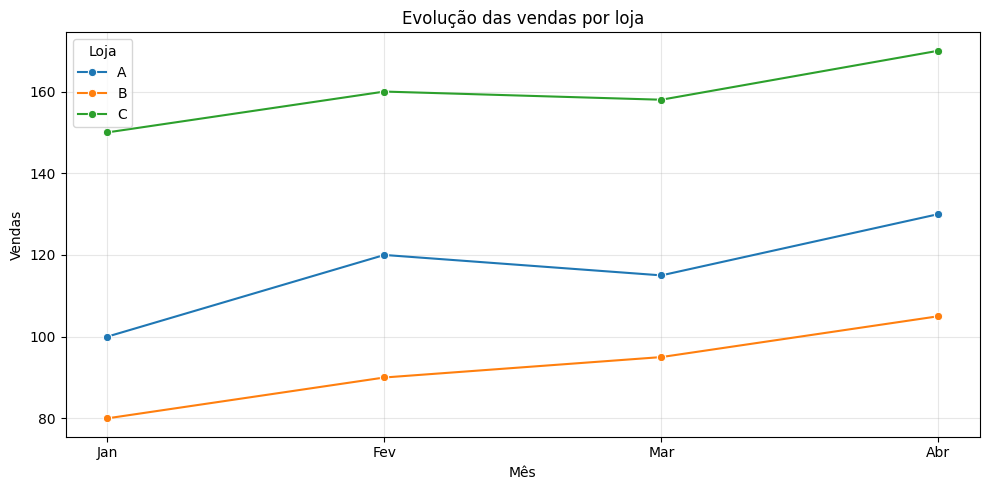

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de linhas
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Mês",
    y="Vendas",
    hue="Loja",
    marker="o"
)

plt.title("Evolução das vendas por loja")
plt.xlabel("Mês")
plt.ylabel("Vendas")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

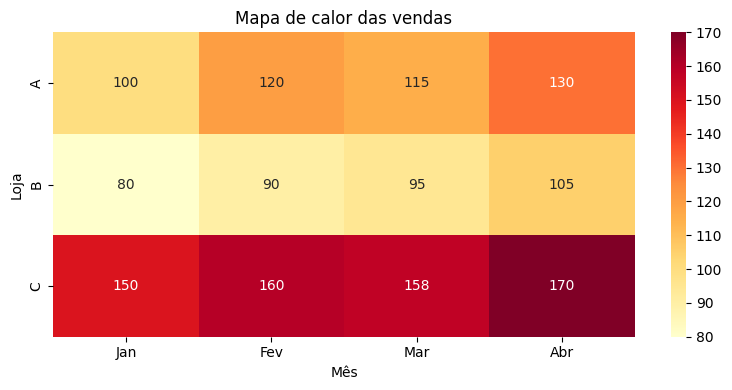

In [52]:
# Mapa de calor

tabela = df.pivot(index="Loja", columns="Mês", values="Vendas")

plt.figure(figsize=(8,4))

sns.heatmap(
    tabela,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Mapa de calor das vendas")
plt.xlabel("Mês")
plt.ylabel("Loja")

plt.tight_layout()
plt.show()

## Identificando a estrutura de painel

Neste exemplo:

- **Loja** representa a unidade
- **Mês** representa o tempo
- **Vendas** representa a variável observada

Transformando em estrutura de painel

In [53]:
df_painel = df.set_index(["Loja", "Mês"])
df_painel

Vendas
Loja Mês        
A    Jan     100
     Fev     120
     Mar     115
     Abr     130
B    Jan      80
     Fev      90
     Mar      95
     Abr     105
C    Jan     150
     Fev     160
     Mar     158
     Abr     170

Agrupando dados por loja

In [54]:
df.groupby("Loja")["Vendas"].mean()

,Vendas
Loja,
A,116.25
B,92.50
C,159.50


Agrupando vendas por mês

In [55]:
df.groupby("Mês")["Vendas"].mean()

/tmp/ipykernel_918/2855898697.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Mês")["Vendas"].mean()


,Vendas
Mês,
Jan,110.000000
Fev,123.333333
Mar,122.666667
Abr,135.000000


In [56]:
df

,Loja,Mês,Vendas
0,A,Jan,100
1,A,Fev,120
2,A,Mar,115
3,A,Abr,130
4,B,Jan,80
5,B,Fev,90
6,B,Mar,95
7,B,Abr,105
8,C,Jan,150
9,C,Fev,160


Tabela em formato matricial

In [57]:
tabela = df.pivot(index="Mês", columns="Loja", values="Vendas")
tabela

Loja,A,B,C
Mês,,,
Jan,100,80,150
Fev,120,90,160
Mar,115,95,158
Abr,130,105,170


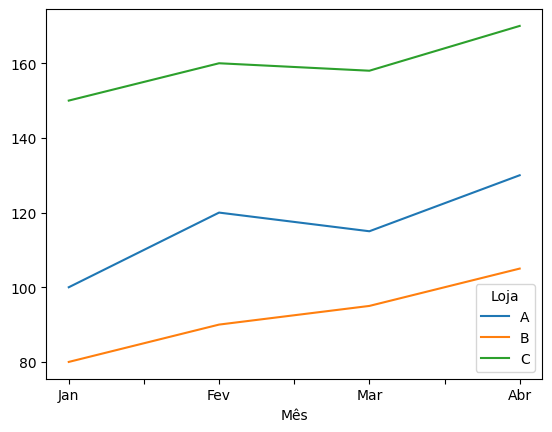

In [58]:
tabela.plot();

# Estrutura 3: Dados em painel, outro exemplo

In [59]:
import pandas as pd

# Criando o DataFrame
df = pd.DataFrame({
    "Loja": [
        "Loja A","Loja A","Loja A","Loja A",
        "Loja B","Loja B","Loja B","Loja B",
        "Loja C","Loja C","Loja C","Loja C"
    ],
    "Mês": [
        "Jan","Fev","Mar","Abr",
        "Jan","Fev","Mar","Abr",
        "Jan","Fev","Mar","Abr"
    ],
    "Vendas": [
        100,120,115,130,
        80,90,95,105,
        150,160,158,170
    ],
    "Funcionários": [
        8,8,9,9,
        6,6,7,7,
        10,10,11,11
    ]
})

df

,Loja,Mês,Vendas,Funcionários
0,Loja A,Jan,100,8
1,Loja A,Fev,120,8
2,Loja A,Mar,115,9
3,Loja A,Abr,130,9
4,Loja B,Jan,80,6
5,Loja B,Fev,90,6
6,Loja B,Mar,95,7
7,Loja B,Abr,105,7
8,Loja C,Jan,150,10
9,Loja C,Fev,160,10


In [60]:
df_painel = df.set_index(["Loja", "Mês"])
df_painel

Vendas  Funcionários
Loja   Mês                      
Loja A Jan     100             8
       Fev     120             8
       Mar     115             9
       Abr     130             9
Loja B Jan      80             6
       Fev      90             6
       Mar      95             7
       Abr     105             7
Loja C Jan     150            10
       Fev     160            10
       Mar     158            11
       Abr     170            11

In [61]:
# produtividade por funcionário
df["Produtividade"] = df["Vendas"] / df["Funcionários"]

df

,Loja,Mês,Vendas,Funcionários,Produtividade
0,Loja A,Jan,100,8,12.500000
1,Loja A,Fev,120,8,15.000000
2,Loja A,Mar,115,9,12.777778
3,Loja A,Abr,130,9,14.444444
4,Loja B,Jan,80,6,13.333333
5,Loja B,Fev,90,6,15.000000
6,Loja B,Mar,95,7,13.571429
7,Loja B,Abr,105,7,15.000000
8,Loja C,Jan,150,10,15.000000
9,Loja C,Fev,160,10,16.000000


In [62]:
df.columns

Index(['Loja', 'Mês', 'Vendas', 'Funcionários', 'Produtividade'], dtype='object')

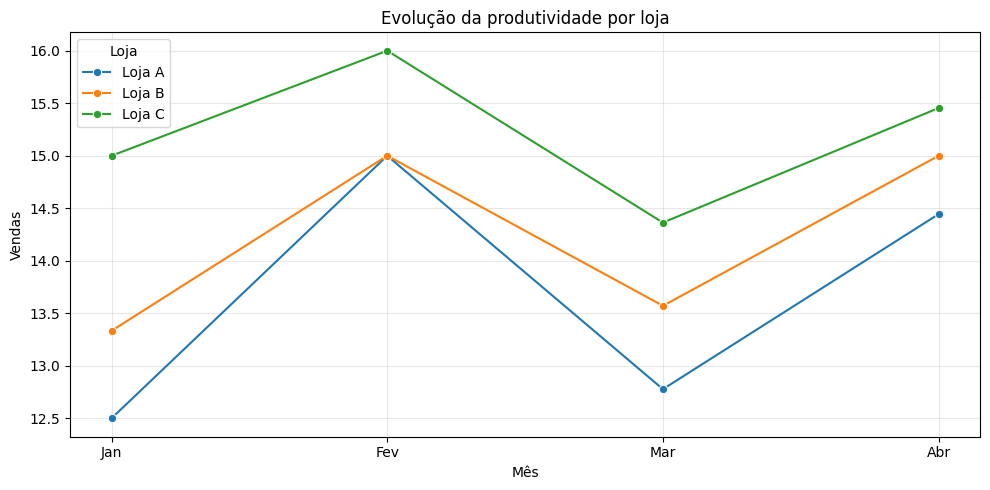

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de linhas
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Mês",
    y="Produtividade",
    hue="Loja",
    marker="o"
)

plt.title("Evolução da produtividade por loja")
plt.xlabel("Mês")
plt.ylabel("Vendas")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Representando dados em painel com MultiIndex

Uma forma muito útil de organizar dados em painel no pandas é usar um **MultiIndex** com duas chaves:

- unidade
- tempo

In [64]:
painel_indexado = df.set_index(["Loja", "Mês"])
painel_indexado

Vendas  Funcionários  Produtividade
Loja   Mês                                     
Loja A Jan     100             8      12.500000
       Fev     120             8      15.000000
       Mar     115             9      12.777778
       Abr     130             9      14.444444
Loja B Jan      80             6      13.333333
       Fev      90             6      15.000000
       Mar      95             7      13.571429
       Abr     105             7      15.000000
Loja C Jan     150            10      15.000000
       Fev     160            10      16.000000
       Mar     158            11      14.363636
       Abr     170            11      15.454545

In [65]:
# Dados da loja A
painel_indexado.loc["Loja A"]

,Vendas,Funcionários,Produtividade
Mês,,,
Jan,100,8,12.500000
Fev,120,8,15.000000
Mar,115,9,12.777778
Abr,130,9,14.444444


In [66]:
# Dados da loja A no mês de fevereiro
painel_indexado.loc[("Loja A", "Fev")]

,Loja A
,Fev
Vendas,120.0
Funcionários,8.0
Produtividade,15.0


## Estatísticas por grupo

In [83]:
# Média de vendas por loja
painel_indexado.groupby("Loja")[["Vendas", "Produtividade"]].mean()

,Vendas,Produtividade
Loja,,
Loja A,116.25,13.680556
Loja B,92.50,14.226190
Loja C,159.50,15.204545


In [68]:
# Média de vendas por mês
painel_indexado.groupby("Mês")["Vendas"].mean()

,Vendas
Mês,
Abr,135.000000
Fev,123.333333
Jan,110.000000
Mar,122.666667


## Transformando em formato matricial com pivot

In [69]:
painel_indexado

Vendas  Funcionários  Produtividade
Loja   Mês                                     
Loja A Jan     100             8      12.500000
       Fev     120             8      15.000000
       Mar     115             9      12.777778
       Abr     130             9      14.444444
Loja B Jan      80             6      13.333333
       Fev      90             6      15.000000
       Mar      95             7      13.571429
       Abr     105             7      15.000000
Loja C Jan     150            10      15.000000
       Fev     160            10      16.000000
       Mar     158            11      14.363636
       Abr     170            11      15.454545

In [70]:
painel_indexado.reset_index()

,Loja,Mês,Vendas,Funcionários,Produtividade
0,Loja A,Jan,100,8,12.500000
1,Loja A,Fev,120,8,15.000000
2,Loja A,Mar,115,9,12.777778
3,Loja A,Abr,130,9,14.444444
4,Loja B,Jan,80,6,13.333333
5,Loja B,Fev,90,6,15.000000
6,Loja B,Mar,95,7,13.571429
7,Loja B,Abr,105,7,15.000000
8,Loja C,Jan,150,10,15.000000
9,Loja C,Fev,160,10,16.000000


In [84]:
painel_pivot = painel_indexado.reset_index().pivot(index="Mês", columns="Loja", values="Vendas")
painel_pivot

Loja,Loja A,Loja B,Loja C
Mês,,,
Abr,130,105,170
Fev,120,90,160
Jan,100,80,150
Mar,115,95,158


In [85]:
painel_pivot = painel_pivot.reset_index()

In [87]:
painel_pivot

Loja,Mês,Loja A,Loja B,Loja C
0,Abr,130,105,170
1,Fev,120,90,160
2,Jan,100,80,150
3,Mar,115,95,158


In [93]:
# ordenar meses (ESSENCIAL)
ordem_meses = ["Jan", "Fev", "Mar", "Abr"]

painel_pivot["Mês"] = pd.Categorical(painel_pivot['Mês'], categories=ordem_meses, ordered=True)

painel_pivot['Mês']

,Mês
0,Abr
1,Fev
2,Jan
3,Mar


In [94]:
painel_pivot.dtypes

,0
Loja,
Mês,category
Loja A,int64
Loja B,int64
Loja C,int64


In [95]:
painel_pivot['Mês'].cat.reorder_categories(ordem_meses, ordered=True)


,Mês
0,Abr
1,Fev
2,Jan
3,Mar


In [96]:
painel_pivot.sort_values("Mês", inplace=True)
painel_pivot

Loja,Mês,Loja A,Loja B,Loja C
2,Jan,100,80,150
1,Fev,120,90,160
3,Mar,115,95,158
0,Abr,130,105,170


In [97]:
painel_pivot

Loja,Mês,Loja A,Loja B,Loja C
2,Jan,100,80,150
1,Fev,120,90,160
3,Mar,115,95,158
0,Abr,130,105,170


In [98]:
painel_pivot.index = painel_pivot['Mês']
painel_pivot

Loja,Mês,Loja A,Loja B,Loja C
Mês,,,,
Jan,Jan,100,80,150
Fev,Fev,120,90,160
Mar,Mar,115,95,158
Abr,Abr,130,105,170


In [99]:
painel_pivot.dtypes

,0
Loja,
Mês,category
Loja A,int64
Loja B,int64
Loja C,int64


In [100]:
painel_pivot = painel_pivot.set_index('Mês')

In [101]:
painel_pivot

Loja,Loja A,Loja B,Loja C
Mês,,,
Jan,100,80,150
Fev,120,90,160
Mar,115,95,158
Abr,130,105,170


In [102]:
# Diferença entre períodos
painel_pivot.diff()

Loja,Loja A,Loja B,Loja C
Mês,,,
Jan,NaN,NaN,NaN
Fev,20.0,10.0,10.0
Mar,-5.0,5.0,-2.0
Abr,15.0,10.0,12.0


In [103]:
(120-100)/100

0.2

In [104]:
(90-80)/80

0.125

In [82]:
# Crescimento percentual entre períodos
# (também chamado de retorno)
painel_pivot.pct_change()

Loja,Loja A,Loja B,Loja C
Mês,,,
Jan,NaN,NaN,NaN
Fev,0.200000,0.125000,0.066667
Mar,-0.041667,0.055556,-0.012500
Abr,0.130435,0.105263,0.075949
